# **PHASE 7 — GRAD-CAM GIẢI THÍCH MÔ HÌNH**

**Cell 7.1: Setup Grad-CAM**

In [1]:
!pip install grad-cam --quiet

import torch
import torch.nn as nn
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2

BASE = 'D:/DoAnTriTueNhanTao/skin_cancer'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
MALIGNANT = ['MEL', 'BCC', 'SCC', 'AK']

class SkinCancerEfficientNet(nn.Module):
    def __init__(self, backbone='efficientnet_b0', num_classes=2, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=False, num_classes=0)
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.head(self.backbone(x))

# Load multi-class model (dùng cho Grad-CAM)
model_mc = SkinCancerEfficientNet(num_classes=8, dropout=0.4).to(DEVICE)
model_mc.load_state_dict(torch.load(f'{BASE}/checkpoints/best_multiclass.pth', map_location=DEVICE))
model_mc.eval()
print("✓ Loaded best_multiclass.pth")


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Loaded best_multiclass.pth


**Cell 7.2: Hàm Grad-CAM cho ảnh đơn**

In [2]:
# Target layer: conv cuối của EfficientNet-B0
target_layers = [model_mc.backbone.conv_head]

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def generate_gradcam(img_path, target_class=None, save_path=None, show=True):
    """Sinh Grad-CAM cho 1 ảnh. target_class=None → dùng lớp dự đoán."""
    rgb_img = np.array(Image.open(img_path).convert('RGB').resize((224, 224))) / 255.0
    input_tensor = preprocess(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)

    # Dự đoán
    with torch.no_grad():
        logits = model_mc(input_tensor)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_class = int(probs.argmax())

    if target_class is None:
        target_class = pred_class

    targets = [ClassifierOutputTarget(target_class)]
    with GradCAM(model=model_mc, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    visualization = show_cam_on_image(rgb_img.astype(np.float32), grayscale_cam, use_rgb=True)

    if show:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(rgb_img); axes[0].set_title('Ảnh gốc'); axes[0].axis('off')
        axes[1].imshow(grayscale_cam, cmap='jet'); axes[1].set_title('Grad-CAM heatmap'); axes[1].axis('off')
        axes[2].imshow(visualization); axes[2].set_title(f'Overlay — dự đoán: {CLASSES[pred_class]} ({probs[pred_class]:.2%})'); axes[2].axis('off')
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    return {
        'pred_class': pred_class,
        'pred_name': CLASSES[pred_class],
        'probs': probs,
        'visualization': visualization
    }

**Cell 7.3: Grad-CAM trên 8 lớp (đúng dự đoán)**

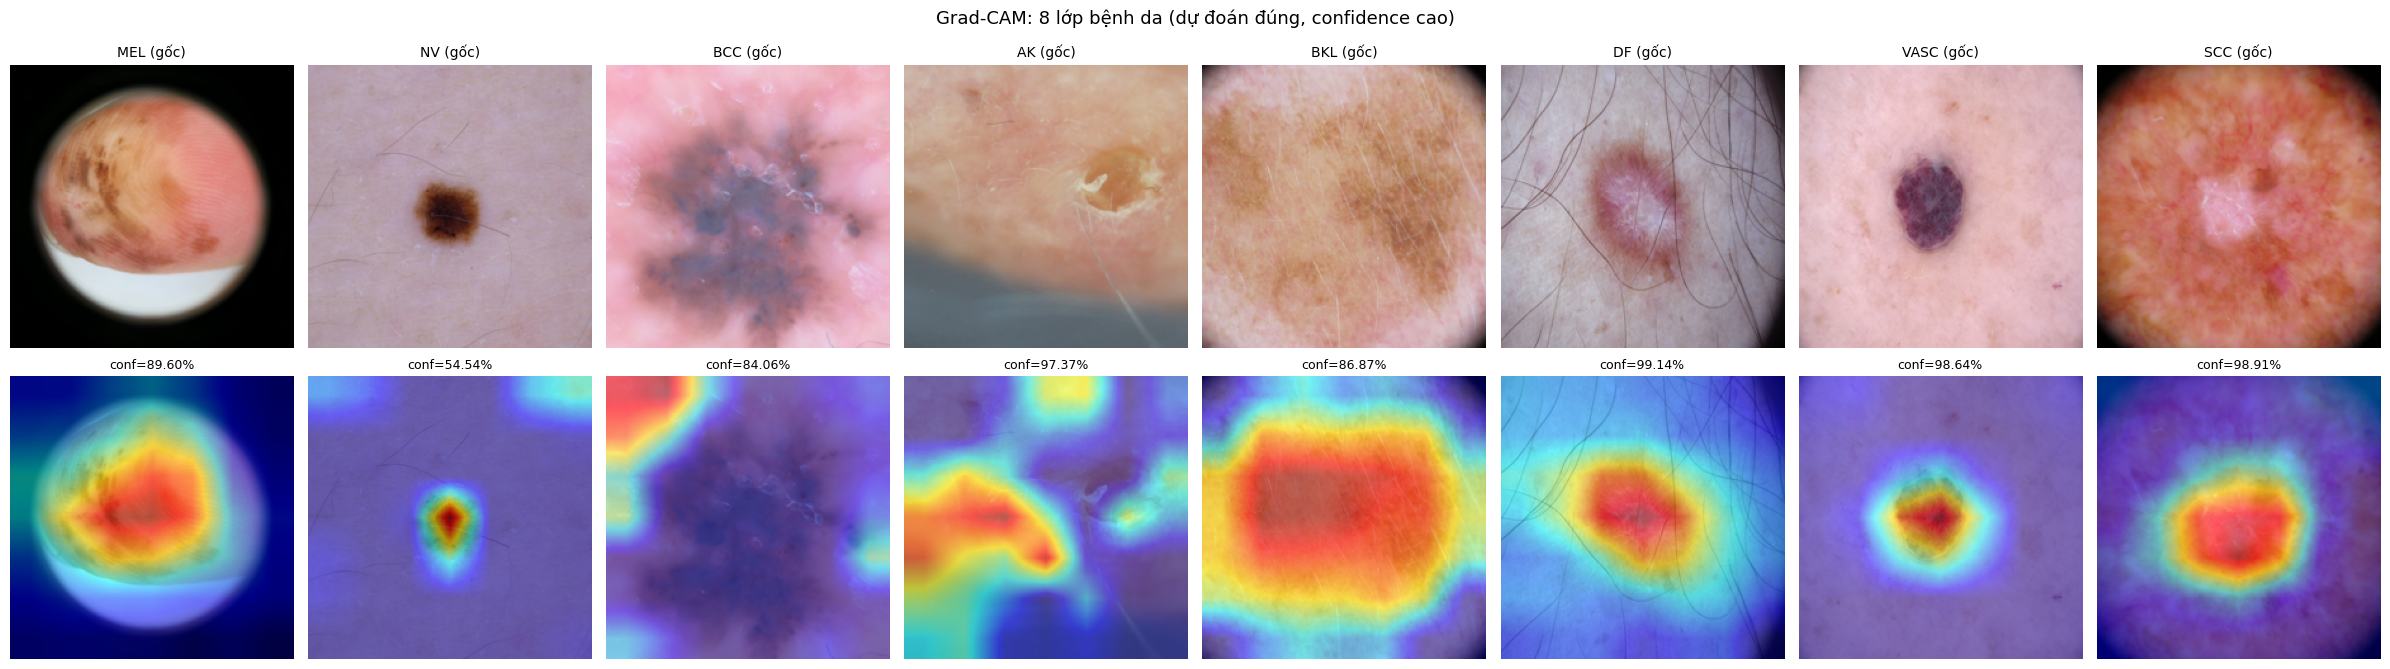

In [4]:
import pandas as pd
mc_pred = pd.read_csv(f'{BASE}/results/multiclass_test_predictions.csv')

# Chọn 1 ảnh mỗi lớp có dự đoán ĐÚNG và confidence cao
fig, axes = plt.subplots(2, 8, figsize=(24, 7))

for i, cls in enumerate(CLASSES):
    sub = mc_pred[(mc_pred['label_name'] == cls) & (mc_pred['pred_label_name'] == cls)].copy()
    sub['conf'] = sub[f'prob_{cls}']
    if len(sub) == 0:
        continue
    row = sub.sort_values('conf', ascending=False).iloc[0]
    img_path = row['img_path']

    rgb_img = np.array(Image.open(img_path).convert('RGB').resize((224, 224))) / 255.0
    input_tensor = preprocess(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    targets = [ClassifierOutputTarget(CLASSES.index(cls))]

    with GradCAM(model=model_mc, target_layers=target_layers) as cam:
        gray = cam(input_tensor=input_tensor, targets=targets)[0]
    vis = show_cam_on_image(rgb_img.astype(np.float32), gray, use_rgb=True)

    axes[0, i].imshow(rgb_img); axes[0, i].set_title(f'{cls} (gốc)', fontsize=10); axes[0, i].axis('off')
    axes[1, i].imshow(vis); axes[1, i].set_title(f'conf={row["conf"]:.2%}', fontsize=9); axes[1, i].axis('off')

plt.suptitle('Grad-CAM: 8 lớp bệnh da (dự đoán đúng, confidence cao)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{BASE}/figures/gradcam_per_class.png', dpi=120, bbox_inches='tight')
plt.show()

**Cell 7.4: Grad-CAM ca bỏ sót ung thư (False Negatives)**

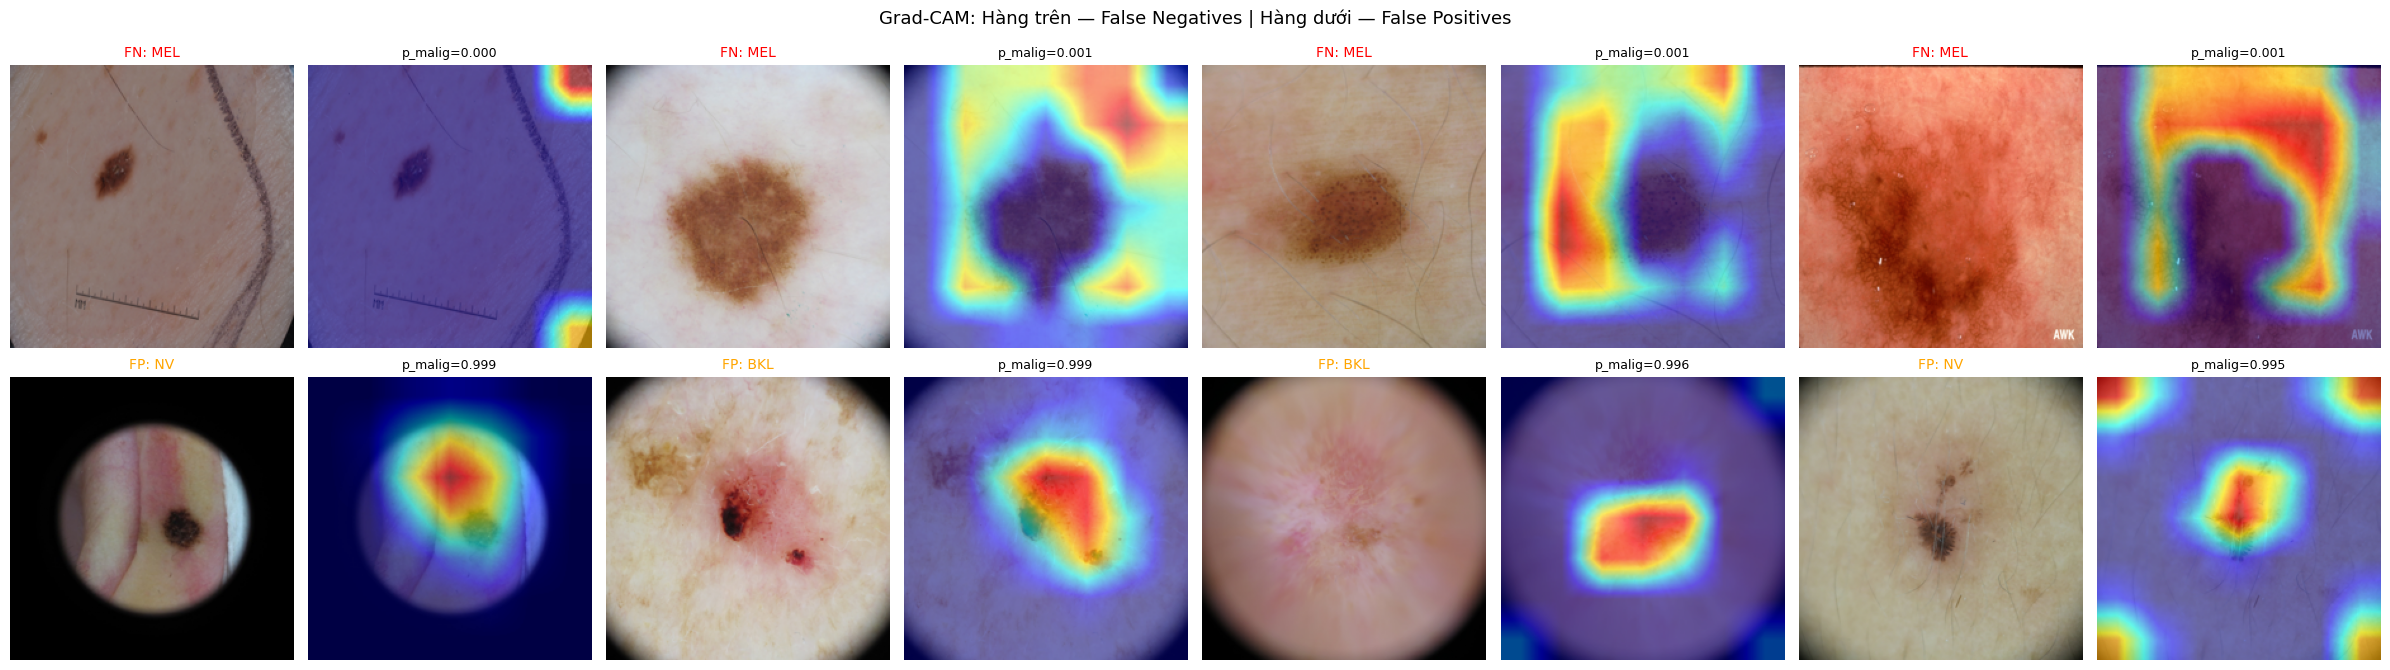

In [5]:
bin_pred = pd.read_csv(f'{BASE}/results/binary_test_predictions.csv')

# Top 4 ca FN (ung thư nhưng đoán lành)
fn_df = bin_pred[(bin_pred['binary_label'] == 1) & (bin_pred['pred_binary'] == 0)]
fn_df = fn_df.sort_values('prob_malignant').head(4)

# Top 4 ca FP (lành nhưng đoán ung thư)
fp_df = bin_pred[(bin_pred['binary_label'] == 0) & (bin_pred['pred_binary'] == 1)]
fp_df = fp_df.sort_values('prob_malignant', ascending=False).head(4)

# Load binary model để Grad-CAM
model_bin = SkinCancerEfficientNet(num_classes=2, dropout=0.3).to(DEVICE)
model_bin.load_state_dict(torch.load(f'{BASE}/checkpoints/best_binary.pth', map_location=DEVICE))
model_bin.eval()
target_layers_bin = [model_bin.backbone.conv_head]

def gradcam_bin(img_path, target_class=1):
    rgb_img = np.array(Image.open(img_path).convert('RGB').resize((224, 224))) / 255.0
    inp = preprocess(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    targets = [ClassifierOutputTarget(target_class)]
    with GradCAM(model=model_bin, target_layers=target_layers_bin) as cam:
        gray = cam(input_tensor=inp, targets=targets)[0]
    return rgb_img, show_cam_on_image(rgb_img.astype(np.float32), gray, use_rgb=True)

fig, axes = plt.subplots(2, 8, figsize=(24, 7))

for i, (_, row) in enumerate(fn_df.iterrows()):
    rgb, vis = gradcam_bin(row['img_path'], target_class=1)
    axes[0, 2*i].imshow(rgb); axes[0, 2*i].set_title(f"FN: {row['label_name']}", fontsize=10, color='red'); axes[0, 2*i].axis('off')
    axes[0, 2*i+1].imshow(vis); axes[0, 2*i+1].set_title(f"p_malig={row['prob_malignant']:.3f}", fontsize=9); axes[0, 2*i+1].axis('off')

for i, (_, row) in enumerate(fp_df.iterrows()):
    rgb, vis = gradcam_bin(row['img_path'], target_class=1)
    axes[1, 2*i].imshow(rgb); axes[1, 2*i].set_title(f"FP: {row['label_name']}", fontsize=10, color='orange'); axes[1, 2*i].axis('off')
    axes[1, 2*i+1].imshow(vis); axes[1, 2*i+1].set_title(f"p_malig={row['prob_malignant']:.3f}", fontsize=9); axes[1, 2*i+1].axis('off')

plt.suptitle('Grad-CAM: Hàng trên — False Negatives | Hàng dưới — False Positives', fontsize=13)
plt.tight_layout()
plt.savefig(f'{BASE}/figures/gradcam_errors.png', dpi=120, bbox_inches='tight')
plt.show()